In [1]:
from load_data.donnees_chargement import load_audience

## Quelles sont les bornes temporelles de la table audience ?

In [2]:
audience = load_audience()
audience.head()

,Annee,TF1,France 2,France 3,Arte
0,1989,41.0,23.4,10.3,NaN
1,1990,41.9,22.1,11.0,NaN
2,1991,42.1,21.3,11.3,NaN
3,1992,41.0,24.0,13.6,NaN
4,1993,41.0,24.7,14.6,0.9


In [3]:
max(audience["Annee"])

2024

In [4]:
min(audience["Annee"])

1989

Les données s'étendent entre 1989 et 2024

## Quelle est l'évolution de l'audience de chaque chaîne

<Axes: title={'center': "Audience totale en fonction de l'année"}, xlabel='Annee'>

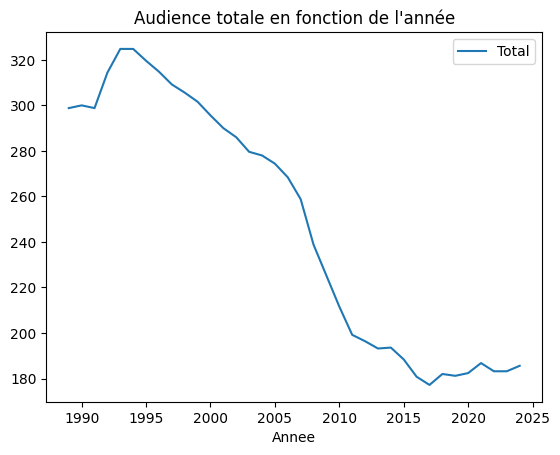

In [26]:
audience_par_annee = audience.drop(columns=["Annee"]).sum(axis=1)
audience["Total"] = audience_par_annee
audience.plot(x="Annee", y="Total", kind="line", title="Audience totale en fonction de l'année")

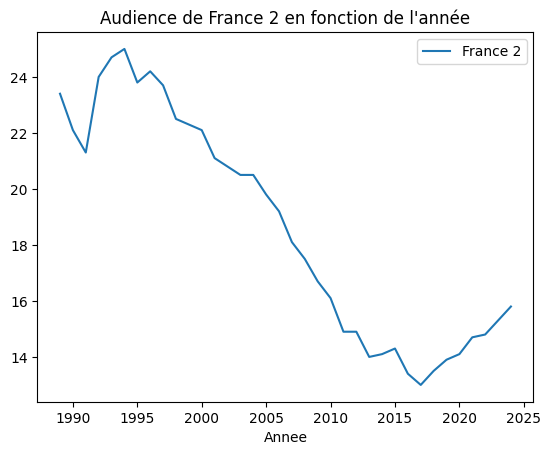

In [ ]:
from utilities.utilities import audience_par_annee

audience_par_annee(audience, "Annee", "France 2")

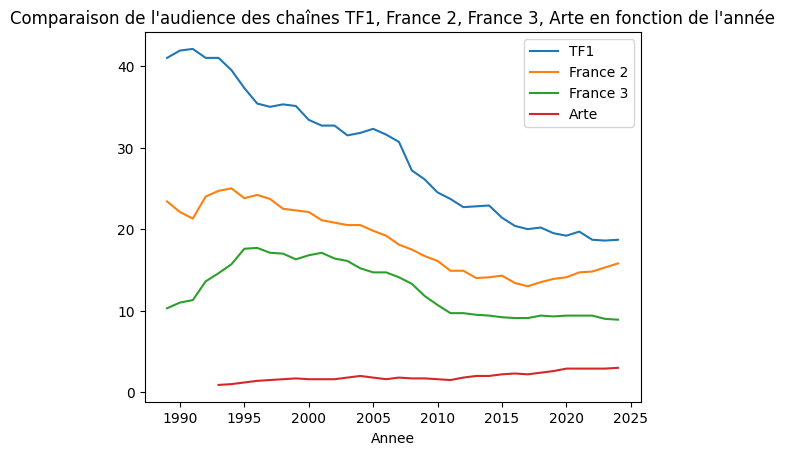

In [ ]:
from utilities.utilities import comparaison_audience

comparaison_audience(audience, "Annee", ["TF1", "France 2", "France 3", "Arte"])

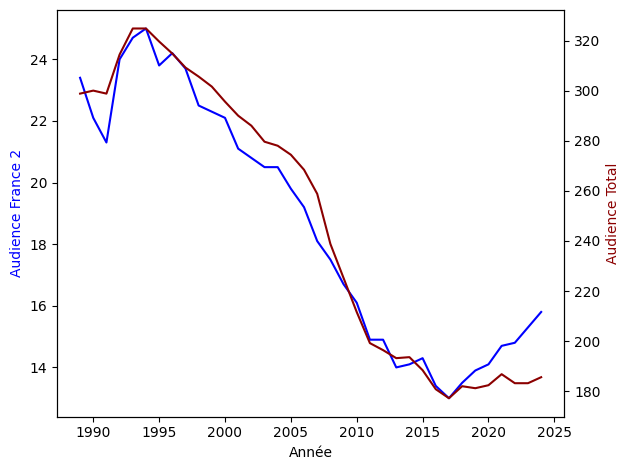

In [ ]:
from utilities.utilities import comparaison_audience_axes

comparaison_audience_axes(audience, "Annee", "France 2", "Total")

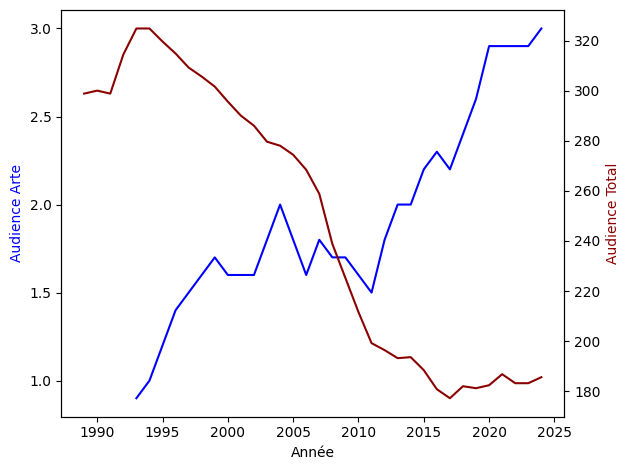

In [47]:
comparaison_audience_axes(audience, "Annee", "Arte", "Total")

# Analyse croisée avec sujet_tele

## Jointure des deux bases

In [48]:
from load_data.donnees_chargement import load_sujet_tele

sujet_tele = load_sujet_tele()
sujet_tele.head()

,Date,Chaîne,Thématique,Nb_sujets,Duree_sec
0,2000-01-02,France 3,Catastrophes,2,235
1,2000-01-02,France 3,Culture-loisirs,1,138
2,2000-01-02,France 3,Environnement,3,306
3,2000-01-02,France 3,International,2,241
4,2000-01-02,France 3,Société,2,160


La table sujet_tele est au format long, il faut donc convertir audience en format long

In [49]:
audience_long = audience.melt(
    id_vars="Annee",
    var_name="Chaine",
    value_name="Audience"
)

In [50]:
audience_long.head()

,Annee,Chaine,Audience
0,1989,TF1,41.0
1,1990,TF1,41.9
2,1991,TF1,42.1
3,1992,TF1,41.0
4,1993,TF1,41.0


La table sujet_annee date les évènements par jour. Convertissons les en années

In [51]:
sujet_tele_year = sujet_tele.groupby([sujet_tele['Date'].dt.to_period('Y'), 'Thématique'])['Prop'].mean().reset_index()


KeyError: 'Column not found: Prop'